In [3]:
import json
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
import torch
from matplotlib.patches import Rectangle
from PIL import Image
from rasterio.windows import Window
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration

plt.rcParams.update({"figure.dpi": 90, "axes.titlesize": 11})

SCIEZKA_ZDJECIA = Path("data/tampa_satelita.tif")
ID_MODELU = "Qwen/Qwen3-VL-4B-Instruct"
FRAGMENT = np.s_[350:950, 1850:2450]  # ten sam kadr "zbiorniki" co w 06_detekcja_obiektow_sam3

URZADZENIE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
TYP = torch.bfloat16 if URZADZENIE != "cpu" else torch.float32

print("Urządzenie:", URZADZENIE, "| torch", torch.__version__)

Urządzenie: mps | torch 2.14.0


Kadr: 600 x 600 px


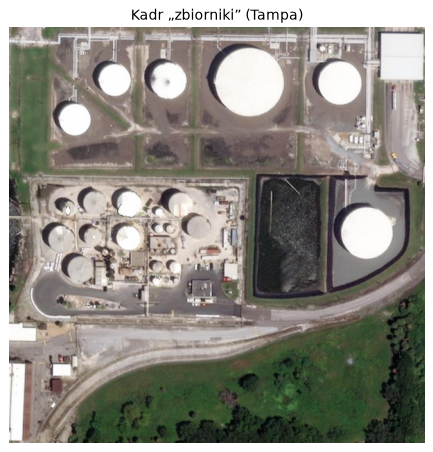

In [4]:
with rasterio.open(SCIEZKA_ZDJECIA) as src:
    okno = Window.from_slices(*FRAGMENT)
    kadr = np.moveaxis(src.read([1, 2, 3], window=okno), 0, -1)

obraz = Image.fromarray(kadr)
print(f"Kadr: {obraz.width} x {obraz.height} px")
plt.figure(figsize=(6, 6))
plt.imshow(obraz)
plt.axis("off")
plt.title("Kadr „zbiorniki” (Tampa)")
plt.show()

In [5]:
t0 = time.perf_counter()
procesor = AutoProcessor.from_pretrained(ID_MODELU)
model = Qwen3VLForConditionalGeneration.from_pretrained(ID_MODELU, dtype=TYP).to(URZADZENIE).eval()
print(f"Załadowano w {time.perf_counter() - t0:.1f} s")


def zapytaj(obraz, polecenie, max_tokenow=512):
    """Obraz + polecenie tekstowe -> odpowiedź modelu (sam nowo wygenerowany tekst, bez promptu)."""
    wiadomosci = [{"role": "user", "content": [{"type": "image", "image": obraz}, {"type": "text", "text": polecenie}]}]
    wejscie = procesor.apply_chat_template(wiadomosci, tokenize=True, add_generation_prompt=True,
                                            return_dict=True, return_tensors="pt").to(URZADZENIE)
    with torch.no_grad():
        wyjscie = model.generate(**wejscie, max_new_tokens=max_tokenow, do_sample=False)
    nowe = wyjscie[:, wejscie["input_ids"].shape[1]:]
    return procesor.batch_decode(nowe, skip_special_tokens=True)[0].strip()

Loading weights: 100%|██████████| 713/713 [00:00<00:00, 6229.63it/s]


Załadowano w 11.7 s


In [6]:
POLECENIE_LICZBA = ("How many round white storage tanks are visible in this satellite image? "
                     "Answer with just the number.")
t0 = time.perf_counter()
odpowiedz_liczba = zapytaj(obraz, POLECENIE_LICZBA, max_tokenow=16)
print(f"Odpowiedź modelu: „{odpowiedz_liczba}” ({time.perf_counter() - t0:.1f} s)")

Odpowiedź modelu: „10” (4.0 s)


In [10]:
POLECENIE_RAMKI = ('Outline the position of every round white storage tank in the image and output all the '
                    'coordinates in JSON format as a list of {"bbox_2d": [x1, y1, x2, y2], "label": "storage tank"}.')
t0 = time.perf_counter()
odpowiedz_ramki = zapytaj(obraz, POLECENIE_RAMKI, max_tokenow=900)
print(f"Czas: {time.perf_counter() - t0:.1f} s, znaków: {len(odpowiedz_ramki)}")
print(odpowiedz_ramki)

Czas: 35.6 s, znaków: 1614
```json
[
	{"bbox_2d": [787, 422, 925, 560], "label": "storage tank"},
	{"bbox_2d": [730, 80, 850, 188], "label": "storage tank"},
	{"bbox_2d": [480, 43, 663, 217], "label": "storage tank"},
	{"bbox_2d": [327, 75, 430, 178], "label": "storage tank"},
	{"bbox_2d": [202, 82, 295, 170], "label": "storage tank"},
	{"bbox_2d": [108, 178, 200, 260], "label": "storage tank"},
	{"bbox_2d": [255, 388, 322, 457], "label": "storage tank"},
	{"bbox_2d": [255, 478, 322, 543], "label": "storage tank"},
	{"bbox_2d": [127, 543, 200, 617], "label": "storage tank"},
	{"bbox_2d": [172, 388, 235, 457], "label": "storage tank"},
	{"bbox_2d": [172, 478, 225, 538], "label": "storage tank"},
	{"bbox_2d": [80, 470, 155, 543], "label": "storage tank"},
	{"bbox_2d": [127, 400, 165, 457], "label": "storage tank"},
	{"bbox_2d": [362, 388, 435, 457], "label": "storage tank"},
	{"bbox_2d": [412, 450, 485, 515], "label": "storage tank"},
	{"bbox_2d": [345, 468, 385, 500], "label": "storage 

In [11]:
WZORZEC_OBIEKTU = re.compile(r'\{\s*"bbox_2d"\s*:\s*\[[^\]]*\]\s*,\s*"label"\s*:\s*"[^"]*"\s*\}')


def wyciagnij_obiekty(tekst):
    """Odpowiedź modelu -> lista {"bbox_2d": [x1,y1,x2,y2], "label": ...}, tylko wpisy z 4 liczbami (0-1000)."""
    obiekty = []
    for wpis in WZORZEC_OBIEKTU.findall(tekst):
        try:
            o = json.loads(wpis)
            x1, y1, x2, y2 = o["bbox_2d"]
        except (json.JSONDecodeError, ValueError, TypeError):
            continue
        if all(isinstance(w, (int, float)) and 0 <= w <= 1000 for w in (x1, y1, x2, y2)):
            obiekty.append(o)
    return obiekty


obiekty = wyciagnij_obiekty(odpowiedz_ramki)
print(f"Sparsowano {len(obiekty)} obiektów (odpowiedź na „ile”: {odpowiedz_liczba}; SAM 3 na tym kadrze: 23)")

Sparsowano 26 obiektów (odpowiedź na „ile”: 10; SAM 3 na tym kadrze: 23)


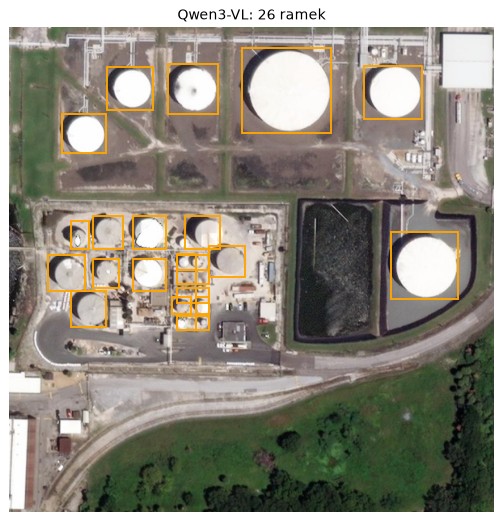

In [12]:
def rysuj_ramki(ax, obraz, obiekty, kolor="orange"):
    """Ramki `bbox_2d` (0-1000 względem boku kadru) -> prostokąty w pikselach obrazu."""
    szer, wys = obraz.size
    ax.imshow(obraz)
    for o in obiekty:
        x1, y1, x2, y2 = o["bbox_2d"]
        x1, x2 = x1 / 1000 * szer, x2 / 1000 * szer
        y1, y2 = y1 / 1000 * wys, y2 / 1000 * wys
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=kolor, linewidth=1.5))
    ax.set_title(f"Qwen3-VL: {len(obiekty)} ramek")
    ax.axis("off")


fig, ax = plt.subplots(figsize=(7, 7))
rysuj_ramki(ax, obraz, obiekty)
plt.show()